In [ ]:
from google.colab import drive 
drive.mount('/content/drive')

In [ ]:
!pip install jsonlines
!pip install transformers
!pip install googletrans==4.0.0-rc1

In [ ]:
import json
import jsonlines
from googletrans import Translator
import pandas as pd
import time
from IPython.display import clear_output
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm, trange
import io
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch import nn
import torch

In [ ]:
from googletrans import Translator
translator = Translator()

In [ ]:
def get_X_y(data_json_file):
    X, y = [], []
    with open(data_json_file, 'r') as json_file:
        json_list = list(json_file)
        for json_str in json_list:
            item = json.loads(json_str)
            text = item['premise']
            ch1 = item['choice1']
            ch2 = item['choice2']
            text_translated = translator.translate(text)
            ch1_translated = translator.translate(ch1)
            ch2_translated = translator.translate(ch2)
            X.append('<cls>' + text_translated.text + '<sep>' + ch1_translated.text + '<sep>' + ch2_translated.text + '<sep>')
            y.append(item['label'])
            time.sleep(1)
            
    return X, y

In [ ]:
def data(x, y):
  df = pd.DataFrame({
    'text': x,
    'label':y
                        })
  return df

In [ ]:
x_train, y_train = get_X_y('/content/drive/MyDrive/The_final/PARus /PARus/train.jsonl')
x_val, y_val = get_X_y('/content/drive/MyDrive/The_final/PARus /PARus/val.jsonl')


In [ ]:
print(y_train)

[0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 

In [ ]:
with jsonlines.open('train_en.jsonl', 'w') as writer:
    writer.write_all(x_train)

with jsonlines.open('val_en.jsonl', 'w') as writer:
  writer.write_all(x_val)

with jsonlines.open('train_y.jsonl', 'w') as writer:
  writer.write_all(y_train)

with jsonlines.open('val_y.jsonl', 'w') as writer:
  writer.write_all(y_val)

from google.colab import files
files.download('train_en.jsonl')
files.download('val_en.jsonl')
files.download('train_y.jsonl')
files.download('val_y.jsonl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#train_df = data(x_train, y_train)
#eval_df = data(x_val, y_val)

#train_df.to_csv('train_df')
#eval_df.to_csv('eval_df')


In [ ]:
#train_df = pd.read_csv('/content/drive/MyDrive/The_final/train_df.csv')
#eval_df = pd.read_csv('/content/drive/MyDrive/The_final/eval_df.csv')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
!pip install sentencepiece

In [ ]:
model

In [ ]:
from transformers import XLNetTokenizerFast, XLNetForSequenceClassification, AdamW

tokenizer = XLNetTokenizerFast.from_pretrained('xlnet-base-cased')
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased')
for name, param in model.named_parameters():
    if 'sequence_summary'  not in name: # classifier layer
	      param.requires_grad = False

    if 'logits_proj'  in name:
        param.requires_grad = True

print(tokenizer)

model.to(device)

tokenized_texts = [tokenizer.tokenize(sent) for sent in x_train]


In [ ]:
from keras.preprocessing.sequence import pad_sequences

input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]
input_ids = pad_sequences(
    input_ids,
    maxlen=512,
    dtype="long",
    truncating="post",
    padding="post"
)
attention_masks = [[float(i>0) for i in seq] for seq in input_ids]

In [ ]:
def preprocessing(inputs, 
                  labels,
                  attention_masks, 
                  test_SIZE, 
                  batch_size):
    train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
        input_ids, y_train, 
        random_state=42,
        test_size=test_SIZE
    )

    train_masks, validation_masks, _, _ = train_test_split(
        attention_masks,
        input_ids,
        random_state=42,
        test_size=test_SIZE
    )

    train_inputs = torch.tensor(train_inputs)
    train_labels = torch.tensor(train_labels)
    train_masks = torch.tensor(train_masks)

    validation_inputs = torch.tensor(validation_inputs)
    validation_labels = torch.tensor(validation_labels)
    validation_masks = torch.tensor(validation_masks)


    train_data = TensorDataset(train_inputs, train_masks, train_labels)
    train_dataloader = DataLoader(
        train_data,
        sampler=RandomSampler(train_data),
        batch_size=batch_size
    )

    validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
    validation_dataloader = DataLoader(
        validation_data,
        sampler=SequentialSampler(validation_data),
        batch_size=batch_size
    )
    return train_dataloader, validation_dataloader

In [ ]:
def train(model, 
             optimizer, 
             train_dataloader, 
             validation_dataloader, 
             scheduler,
             num_epochs):
  train_loss_set = []
  train_loss = 0

  for epoch in range(num_epochs):
    model.train()

    for step, batch in enumerate(train_dataloader):
       batch = tuple(t.to(device) for t in batch)
       b_input_ids, b_input_mask, b_labels = batch
       optimizer.zero_grad()
      
       outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels, token_type_ids=None)
       train_loss_set.append(outputs[0].item())

       outputs[0].backward()
       optimizer.step()
       scheduler.step()

       train_loss += outputs[0].item()

       clear_output(True)
       plt.plot(train_loss_set)
       plt.title("Training loss")
       plt.xlabel("Batch")
       plt.ylabel("Loss")
       plt.show()
  
    model.eval()

    valid_preds, valid_labels = [], []

    for batch in validation_dataloader:
      batch = tuple(t.to(device) for t in batch)

      b_input_ids, b_attention_mask, b_labels = batch

      with torch.no_grad():
        logits = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels, token_type_ids=None)

        loss = logits[0].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        #batch_preds = np.argmax(logits[2], axis=1)
        #batch_labels = np.concatenate(label_ids)  

        #valid_preds.extend(batch_preds)
        #valid_labels.extend(batch_labels)


      #print("accuracy score {0:.2f}%".format(
         # accuracy_score(valid_labels, valid_preds) * 100
      #))
      #print("F1: {0:.2f}%".format(
       # f1_score(valid_labels, valid_preds, average='weighted') * 100
      #))


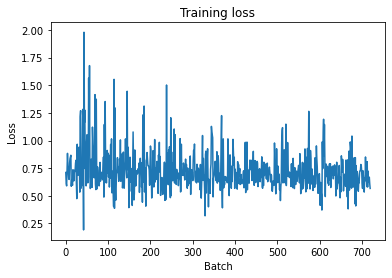

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-3)
NUM_EPOCH = 10
BATCH = 5
train_dataloader, validation_dataloader = preprocessing(inputs=input_ids,
                                                        labels=y_train,
                                                        attention_masks=attention_masks,
                                                        test_SIZE=0.1, batch_size=BATCH)




scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=len(train_dataloader), 
                                            num_training_steps=len(train_dataloader)*NUM_EPOCH)

train(model=model,
      optimizer=optimizer,
      scheduler=scheduler,
      train_dataloader=train_dataloader,
      validation_dataloader=validation_dataloader,
      num_epochs=NUM_EPOCH,
      )



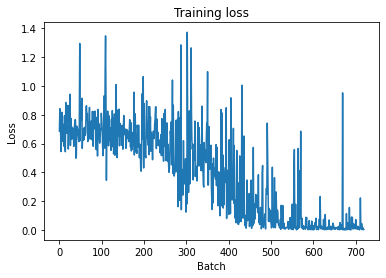

In [ ]:
for name, param in model.named_parameters():
		if 'sequence_summary'or 'logits_proj' not in name: # classifier layer
		    param.requires_grad = True




optimizer = AdamW(model.parameters(), lr=2e-5)
NUM_EPOCH = 10
BATCH = 5
train_dataloader, validation_dataloader = preprocessing(inputs=input_ids,
                                                        labels=y_train,
                                                        attention_masks=attention_masks,
                                                        test_SIZE=0.1, batch_size=BATCH)




scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=len(train_dataloader), 
                                            num_training_steps=len(train_dataloader)*NUM_EPOCH)

train(model=model,
      optimizer=optimizer,
      scheduler=scheduler,
      train_dataloader=train_dataloader,
      validation_dataloader=validation_dataloader,
      num_epochs=NUM_EPOCH)


In [ ]:
tokenized_texts = [tokenizer.tokenize(sent) for sent in x_val]


input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]

input_ids = pad_sequences(
    input_ids,
    maxlen=512,
    dtype="long",
    truncating="post",
    padding="post"
)
attention_masks = [[float(i>0) for i in seq] for seq in input_ids]

In [ ]:
prediction_inputs = torch.tensor(input_ids)
prediction_masks = torch.tensor(attention_masks)
prediction_labels = torch.tensor(y_val)


prediction_data = TensorDataset(
    prediction_inputs,
    prediction_masks,
    prediction_labels

)


prediction_dataloader = DataLoader(
    prediction_data, 
    sampler=SequentialSampler(prediction_data),
    batch_size=15
)

In [ ]:
import torch.nn.functional as F
from sklearn import metrics



acc = []

model.eval()
test_preds, test_labels = [], []

for batch in prediction_dataloader:
    batch = tuple(t.to(device) for t in batch)
    
    b_input_ids, b_input_mask, b_labels  = batch
  
    
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs[0]
    prediction = torch.argmax(logits, dim=1)
    targets = b_labels.cpu().detach().numpy()
    prediction = prediction.cpu().detach().numpy()
    accuracy = metrics.accuracy_score(targets, prediction)

    acc.append(accuracy)

print(sum(acc)/len(acc))

0.43333333333333324
